0#%% md
# Dimensioning a village battery for [Solbyn](https://solbyn.org/)

Knowns:
* AC cables connecting (in decreasing order of energy):
  1. A windmill far outside the village, outside the village AC voltage transformer.
  2. Northern and southern half-village with 25 households. All with hot-water accumulators. Many with wood stoves. Some with PEV panels. One with a solar heat panel.
  3. Eastern installation: PEV panels, solar heat panels, a large hot-water accumulator, a washing facility, a kindergarten, a cafeteria, a guest apartment.
  4. Western installation: PEV panels, 14 kWh electric battery and 20 EVs.
  5. Electric outdoor lighting.
* Data on power transfers to one household.
* Data on power transfers to and from the village except the windmill and households.

Suggestions:
* Increase electric battery to 36 kWh.
* Load-balance all households within each 10 buildings.
* Upgrade EV chargers to support vehicle-to-grid (VTG/VTX).
* Load-balance everything except the windmill.
* Load-balance everything including the windmill.

General questions:
* How many years can we expect before pay-off of a battery capacity increase to 36 kWh?
* Would the battery investment make sense with VTG?
* Would the battery investment make sense with everything except the windmill balanced?
* Would the battery investment make sense with everything including the windmill balanced?

First task:
* Is a flat electricity energy daily consumption a relevant approximation for dimensioning a battery that may later be used by all 50 households too?
* Use https://github.com/Arcascope/circadian to calculate daily and nightly energy transfers!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
from circadian.plots import Actogram
from circadian.lights import LightSchedule
from circadian.models import Forger99, Jewett99, Hannay19, Hannay19TP

In [2]:
days_night = 3
days_day = 2
slam_shift = LightSchedule.ShiftWork(lux=300.0, days_on=days_night, days_off=days_day)

total_days = 30
time = np.arange(0, 24*total_days, 0.10)
light_values = slam_shift(time)

f_model = Forger99()
kj_model = Jewett99()
spm_model = Hannay19()
tpm_model = Hannay19TP()

equilibration_reps = 2
initial_conditions_forger = f_model.equilibrate(time, light_values, equilibration_reps)
initial_conditions_kj = kj_model.equilibrate(time, light_values, equilibration_reps)
initial_conditions_spm = spm_model.equilibrate(time, light_values, equilibration_reps)
initial_conditions_tpm = tpm_model.equilibrate(time, light_values, equilibration_reps)

E:\home\joakimbits\village_battery\.venv\Lib\site-packages\circadian\models.py:431: UserWarning: The model did not equilibrate. Try increasing the number of loops.
  warnings.warn("The model did not equilibrate. Try increasing the number of loops.")


In [3]:
trajectory_f = f_model(time, initial_conditions_forger, light_values)
trajectory_kj = kj_model(time, initial_conditions_kj, light_values)
trajectory_spm = spm_model(time, initial_conditions_spm, light_values)
trajectory_tpm = tpm_model(time, initial_conditions_tpm, light_values)

In [4]:
dlmo_f = f_model.dlmos()
dlmo_kj = kj_model.dlmos()
dlmo_spm = spm_model.dlmos()
dlmo_tpm = tpm_model.dlmos()

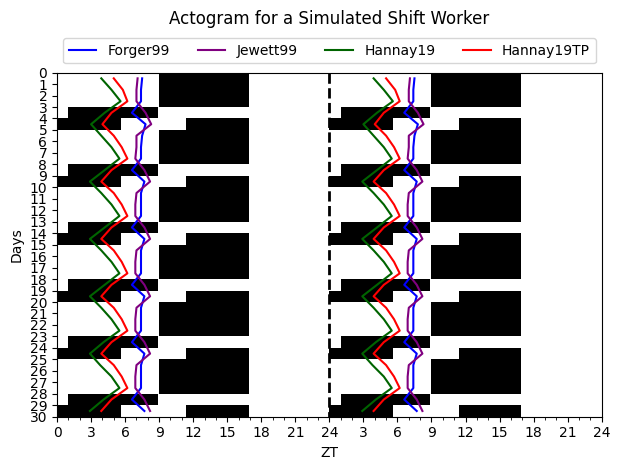

In [5]:
acto = Actogram(time, light_vals=light_values, opacity=1.0, smooth=False)
acto.plot_phasemarker(dlmo_f, color='blue')
acto.plot_phasemarker(dlmo_spm, color='darkgreen')
acto.plot_phasemarker(dlmo_tpm, color='red')
acto.plot_phasemarker(dlmo_kj, color='purple')
# legend
blue_line = lines.Line2D([], [], color='blue', label='Forger99')
green_line = lines.Line2D([], [], color='darkgreen', label='Hannay19')
red_line = lines.Line2D([], [], color='red', label='Hannay19TP')
purple_line = lines.Line2D([], [], color='purple', label='Jewett99')

plt.legend(handles=[blue_line, purple_line, green_line, red_line],
           loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4)
plt.title("Actogram for a Simulated Shift Worker", pad=35)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

In [7]:
# Import with closest latitude/longitude time zone for Solbyn as default
TZ = 'Europe/Copenhagen'
def read_european_table(dataset: str, datum='Datum', tz=TZ) -> pd.DataFrame:
    df = pd.read_table(dataset, sep=';', decimal=',', index_col=datum, parse_dates=[datum], na_values=["-", "—"])
    df.index = df.index.tz_localize(tz, nonexistent="shift_forward", ambiguous="NaT")
    return df


In [8]:
systems = read_european_table('data/El - Sandbyvägen 196, Dalby.csv')
household = read_european_table('data/El - Sandbyvägen 158, Dalby.csv')

In [9]:
systems.head()

,Produktion,El kWh,Utomhustemperatur,kWh - 2023-01-01 - 2023-12-31,T(°C) - 2023-01-01 - 2023-12-31
Datum,,,,,
2024-01-01 00:00:00+01:00,0.0,6.17,4.2,8.79,5.7
2024-01-01 01:00:00+01:00,0.0,6.12,4.1,8.71,6.0
2024-01-01 02:00:00+01:00,0.0,5.61,3.9,7.95,6.6
2024-01-01 03:00:00+01:00,0.0,5.86,3.8,5.28,6.5
2024-01-01 04:00:00+01:00,0.0,5.91,3.8,5.84,5.9


In [10]:
household.head()

,El kWh,Utomhustemperatur,kWh - 2023-01-01 - 2023-12-31,T(°C) - 2023-01-01 - 2023-12-31
Datum,,,,
2024-01-01 00:00:00+01:00,1.412,4.2,1.148,5.7
2024-01-01 01:00:00+01:00,1.219,4.1,0.856,6.0
2024-01-01 02:00:00+01:00,2.172,3.9,0.891,6.6
2024-01-01 03:00:00+01:00,2.133,3.8,1.238,6.5
2024-01-01 04:00:00+01:00,1.179,3.8,1.187,5.9


In [11]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="village_battery")
location = geolocator.geocode("Sandbyvägen 196, Dalby, Sweden")
location

Location(196, Sandbyvägen, Dalby, Lunds kommun, Skåne län, 247 51, Sverige, (55.6731593, 13.3532784, 0.0))

In [12]:
import requests

latitude, longitude, _ = location.point
OPENTOPO = "https://api.opentopodata.org/v1/"
elevation = float(requests.get(f"{OPENTOPO}aster30m?locations={latitude},{longitude}").json()['results'][0]['elevation'])
elevation

86.0

In [13]:
from pvlib import location, solarposition, irradiance

site = location.Location(latitude=latitude, longitude=longitude, tz=TZ, altitude=elevation, name="Solbyn")
site

Location: 
  name: Solbyn
  latitude: 55.6731593
  longitude: 13.3532784
  altitude: 86.0
  tz: Europe/Copenhagen

In [14]:
datum = systems.index
clearsky = site.get_clearsky(datum, model="ineichen")
clearsky

,ghi,dni,dhi
Datum,,,
2024-01-01 00:00:00+01:00,0.0,0.0,0.0
2024-01-01 01:00:00+01:00,0.0,0.0,0.0
2024-01-01 02:00:00+01:00,0.0,0.0,0.0
2024-01-01 03:00:00+01:00,0.0,0.0,0.0
2024-01-01 04:00:00+01:00,0.0,0.0,0.0
...,...,...,...
2024-12-31 19:00:00+01:00,0.0,0.0,0.0
2024-12-31 20:00:00+01:00,0.0,0.0,0.0
2024-12-31 21:00:00+01:00,0.0,0.0,0.0


In [15]:
print('>>> systems.head()\n', systems.head())
print('>>> site\n', site)
print('>>> clearsky\n', clearsky)

>>> systems.head()
                            Produktion  El kWh  Utomhustemperatur  \
Datum                                                              
2024-01-01 00:00:00+01:00         0.0    6.17                4.2   
2024-01-01 01:00:00+01:00         0.0    6.12                4.1   
2024-01-01 02:00:00+01:00         0.0    5.61                3.9   
2024-01-01 03:00:00+01:00         0.0    5.86                3.8   
2024-01-01 04:00:00+01:00         0.0    5.91                3.8   

                           kWh - 2023-01-01  - 2023-12-31  \
Datum                                                       
2024-01-01 00:00:00+01:00                            8.79   
2024-01-01 01:00:00+01:00                            8.71   
2024-01-01 02:00:00+01:00                            7.95   
2024-01-01 03:00:00+01:00                            5.28   
2024-01-01 04:00:00+01:00                            5.84   

                           T(°C) - 2023-01-01  - 2023-12-31  
Datum        

In [16]:
TILT_DEG    = 25.0
AZIMUTH_DEG = 135.0   # 0=N, 90=E, 180=S, 270=W → SE = 135°
ALBEDO      = 0.2
K_ILL       = 120.0

In [17]:
solpos = solarposition.get_solarposition(
    time=datum, latitude=latitude, longitude=longitude, altitude=elevation
)

In [18]:
poa = irradiance.get_total_irradiance(
    surface_tilt=TILT_DEG,
    surface_azimuth=AZIMUTH_DEG,
    dni=clearsky["dni"],
    ghi=clearsky["ghi"],
    dhi=clearsky["dhi"],
    solar_zenith=solpos["apparent_zenith"],
    solar_azimuth=solpos["azimuth"],
    albedo=ALBEDO,
)

In [19]:
poa_global = poa["poa_global"]

In [20]:
poa_global

Datum
2024-01-01 00:00:00+01:00    0.0
2024-01-01 01:00:00+01:00    0.0
2024-01-01 02:00:00+01:00    0.0
2024-01-01 03:00:00+01:00    0.0
2024-01-01 04:00:00+01:00    0.0
                            ... 
2024-12-31 19:00:00+01:00    0.0
2024-12-31 20:00:00+01:00    0.0
2024-12-31 21:00:00+01:00    0.0
2024-12-31 22:00:00+01:00    0.0
2024-12-31 23:00:00+01:00    0.0
Name: poa_global, Length: 8783, dtype: float64

In [21]:
import plotly.express as px
import plotly.io as pio

#pio.renderers.default = "plotly_mimetype"  # Or PLOTLY_RENDERER=plotly_mimetype

# Assume df is your DataFrame with a tz-aware DatetimeIndex and one or more value columns
x = poa_global.index.tz_convert(TZ).tz_localize(None)
df = poa_global.to_frame(name='poa_global')

fig = px.line(
    df.assign(__x__=x),                 # keep columns, add naive datetime
    x="__x__",                          # x-axis
    y=[c for c in df.columns],          # all numeric columns; or y="y" for single series
    title="Interactive time series",
)
fig.update_layout(
    hovermode="x unified",
    xaxis_title="Time",
    yaxis_title="Value",
    xaxis=dict(rangeslider=dict(visible=True)),  # drag to zoom with slider
)
fig.show()

In [22]:
%whos

Variable                    Type                   Data/Info
------------------------------------------------------------
ALBEDO                      float                  0.2
AZIMUTH_DEG                 float                  135.0
Actogram                    type                   <class 'circadian.plots.Actogram'>
Forger99                    ABCMeta                <class 'circadian.models.Forger99'>
Hannay19                    ABCMeta                <class 'circadian.models.Hannay19'>
Hannay19TP                  ABCMeta                <class 'circadian.models.Hannay19TP'>
Jewett99                    ABCMeta                <class 'circadian.models.Jewett99'>
K_ILL                       float                  120.0
LightSchedule               type                   <class 'circadian.lights.LightSchedule'>
Nominatim                   type                   <class 'geopy.geocoders.nominatim.Nominatim'>
OPENTOPO                    str                    https://api.opentopodata.org/v1/


In [25]:
# Daily energy + weekly scan (uses existing systems, pd, go, TZ)
import plotly.graph_objects as go

# 1) Index → local-naive
t = pd.to_datetime(systems.index)
if getattr(t, "tz", None) is not None:
    t = t.tz_convert(TZ).tz_localize(None)
sys_ = systems.copy()
sys_.index = t

# 2) Column bindings (edit if different)
prod_col = "Produktion"          # PV production (assumed kWh per interval)
grid_in_col = "El kWh"           # Grid import (kWh per interval)
temp_col = "Utomhustemperatur"   # Ambient °C (optional)

# 3) Daily aggregates (kWh/day, °C/day)
prod_kwh_d     = sys_[prod_col].resample("D").sum().rename("PV (kWh)")
grid_in_kwh_d  = sys_[grid_in_col].resample("D").sum().rename("Grid in (kWh)")
temp_c_d       = (sys_[temp_col].resample("D").mean().rename("Ambient (°C)")
                  if temp_col in sys_.columns else None)
net_kwh_d      = (prod_kwh_d - grid_in_kwh_d).rename("Net (kWh)")  # proxy: export minus import (may differ from true feed-in)

# 4) Plot: bars (prod/import), net line, temp on y2; weekly range buttons
fig_weekly = go.Figure()
fig_weekly.add_bar(x=prod_kwh_d.index,    y=prod_kwh_d.values,    name=prod_kwh_d.name)
fig_weekly.add_bar(x=grid_in_kwh_d.index, y=-grid_in_kwh_d.values, name="Grid in (kWh)")  # negative to stack below zero
fig_weekly.add_scatter(x=net_kwh_d.index, y=net_kwh_d.values, name=net_kwh_d.name, mode="lines")
if temp_c_d is not None:
    fig_weekly.add_scatter(x=temp_c_d.index, y=temp_c_d.values, name=temp_c_d.name, mode="lines", yaxis="y2")

fig_weekly.update_layout(
    title="Daily energy transfer (PV vs Grid In) — weekly scan",
    barmode="relative", hovermode="x unified",
    xaxis=dict(
        title="Date",
        rangeselector=dict(buttons=[
            dict(count=7,  step="day",   label="1w", stepmode="backward"),
            dict(count=14, step="day",   label="2w", stepmode="backward"),
            dict(count=1,  step="month", label="1m", stepmode="backward"),
            dict(step="all")
        ]),
        rangeslider=dict(visible=False),
    ),
    yaxis=dict(title="Energy (kWh)"),
    yaxis2=(dict(title="Ambient (°C)", overlaying="y", side="right") if temp_c_d is not None else None),
)
fig_weekly.show()

In [26]:
# Uses existing: pd, np, go, TZ, systems

# --- 0) Local-naive index
t = pd.to_datetime(systems.index)
if getattr(t, "tz", None) is not None:
    t = t.tz_convert(TZ).tz_localize(None)
sys_ = systems.copy(); sys_.index = t

# --- 1) Net energy per sample (kWh). Assumes columns are kWh per interval.
prod_col, grid_in_col = "Produktion", "El kWh"
net_e = (sys_[prod_col] - sys_[grid_in_col]).rename("net_kWh")

# --- 2) DAILY Net (kWh/day) — weekly/daily scanning
net_kwh_d = net_e.resample("D").sum()

# color by sign
colors = np.where(net_kwh_d.values >= 0, "rgba(33,150,243,0.7)", "rgba(244,67,54,0.7)")

fig_week_net = go.Figure()
fig_week_net.add_bar(x=net_kwh_d.index, y=net_kwh_d.values, name="Net (kWh/day)", marker_color=colors)
fig_week_net.update_layout(
    title="Daily Net Energy (kWh) — use 1w/2w to scan weeks",
    xaxis=dict(
        title="Date",
        rangeselector=dict(buttons=[
            dict(count=7,  step="day",   label="1w", stepmode="backward"),
            dict(count=14, step="day",   label="2w", stepmode="backward"),
            dict(count=1,  step="month", label="1m", stepmode="backward"),
            dict(step="all")
        ]),
        rangeslider=dict(visible=False),
    ),
    yaxis=dict(title="kWh/day"),
    hovermode="x unified",
)
fig_week_net.show()

# --- 3) TYPICAL 24h Net profile (kWh per hour-of-day)
# If your samples aren't hourly, this still averages per clock hour across days.
net_kwh_by_hod = net_e.groupby(net_e.index.hour).mean().reindex(range(24), fill_value=0.0)
hod = np.arange(24)

# --- 4) Simple same-day storage model on the typical day
cap_kwh = 30.0        # capacity to test (edit)
eta_rt  = 0.90        # round-trip efficiency (edit)
soc0    = 0.5 * cap_kwh

soc = np.zeros(24); soc[0] = soc0
residual = np.zeros(24)   # after storage (positive=export, negative=import)
soc_now = soc0

for h in range(24):
    e = net_kwh_by_hod.iloc[h]  # + = surplus, - = deficit
    if e >= 0:
        # charge with efficiency on the way in
        charge = min(e * eta_rt, cap_kwh - soc_now)
        spill = e * eta_rt - charge
        soc_now += charge
        residual[h] = spill / eta_rt  # show spill as remaining export (undo efficiency for display)
    else:
        # discharge with efficiency on the way out
        need = -e
        discharge = min(need / eta_rt, soc_now)
        soc_now -= discharge
        unmet = need - discharge * eta_rt
        residual[h] = -(unmet)        # negative import remaining
    soc[h] = soc_now

# Optional: make SOC end roughly where it started (cyclic day)
# This keeps plots comparable; skip if you want raw outcome.
soc_shift = soc_now - soc0
if abs(soc_shift) > 1e-6:
    soc -= soc_shift
    soc_now -= soc_shift

# --- 5) Plot typical-day bars (original vs after-storage) + SOC
fig_daily = go.Figure()
fig_daily.add_bar(x=hod, y=net_kwh_by_hod.values, name="Net (kWh/h)")
fig_daily.add_bar(x=hod, y=residual, name="After storage (kWh/h)")
fig_daily.add_scatter(x=hod, y=soc, name="SOC (kWh)", mode="lines", yaxis="y2")

fig_daily.update_layout(
    title="Typical 24h Net profile — storage shift test",
    barmode="relative",
    xaxis=dict(title="Hour of day (local)"),
    yaxis=dict(title="kWh per hour"),
    yaxis2=dict(title="Battery SOC (kWh)", overlaying="y", side="right"),
    hovermode="x unified",
)
fig_daily.show()


In [28]:
# Battery sizing realism test: Actual vs Flat-in-day net profile
# Uses existing: pd, np, go, TZ, systems
# Assumptions: 'Produktion' and 'El kWh' are kWh-per-interval (not cumulative).

# --- 0) Index → local-naive
t = pd.to_datetime(systems.index)
if getattr(t, "tz", None) is not None:
    t = t.tz_convert(TZ).tz_localize(None)
sys_ = systems.copy(); sys_.index = t

# --- 1) Columns -> per-interval net energy (kWh)
prod_col, grid_in_col = "Produktion", "El kWh"
if prod_col not in sys_.columns or grid_in_col not in sys_.columns:
    raise ValueError(f"Expected columns '{prod_col}' and '{grid_in_col}' in systems = {list(sys_.columns)}")

net_e = (sys_[prod_col] - sys_[grid_in_col]).rename("net_kWh")  # + surplus, - deficit

# --- 2) Battery sizing helper (per-day time series -> required capacity)
# Split round-trip efficiency η into charge/discharge: ηc = ηd = sqrt(ηrt)
def capacity_needed_kwh(e_series: pd.Series, eta_rt: float = 0.90) -> float:
    if e_series.empty:
        return 0.0
    eta = np.sqrt(eta_rt)
    soc = 0.0
    soc_min = 0.0
    soc_max = 0.0
    for e in e_series.values:
        if e >= 0:
            # charge; only a fraction lands in the battery
            soc += e * eta
        else:
            # discharge; battery must provide more due to losses
            soc += e / eta
        if soc < soc_min: soc_min = soc
        if soc > soc_max: soc_max = soc
    return float(soc_max - soc_min)  # kWh

# --- 3) Per-day comparison: actual vs flat
groups = net_e.groupby(net_e.index.normalize())  # one group per day
records = []
for day, g in groups:
    if len(g) < 2:
        continue
    true_cap = capacity_needed_kwh(g)
    flat_val = g.sum() / len(g)   # same daily energy, spread evenly
    flat_cap = capacity_needed_kwh(pd.Series(np.full(len(g), flat_val), index=g.index))
    ratio = (true_cap / flat_cap) if flat_cap > 0 else (np.inf if true_cap > 0 else 1.0)
    records.append({"day": day, "true_cap": true_cap, "flat_cap": flat_cap, "ratio_true_over_flat": ratio})

daily_caps = pd.DataFrame.from_records(records).set_index("day").sort_index()

# --- 4) Summary: is "flat day" acceptable?
# If ratio ≈ 1, flat is fine; >>1 means flat underestimates capacity.
if not daily_caps.empty:
    q = daily_caps["ratio_true_over_flat"].replace(np.inf, np.nan).dropna()
    msg = (
        f"Days analyzed: {len(daily_caps)}\n"
        f"Median capacity (true): {daily_caps['true_cap'].median():.2f} kWh\n"
        f"Median capacity (flat): {daily_caps['flat_cap'].median():.2f} kWh\n"
        f"Median ratio (true/flat): {q.median():.2f}\n"
        f"90th pct ratio: {q.quantile(0.90):.2f}\n"
    )
else:
    msg = "No daily data available."

print(msg)

# --- 5) Plot daily capacity needed (true) with weekly scan buttons
fig_weekly_cap = go.Figure()
fig_weekly_cap.add_bar(
    x=daily_caps.index, y=daily_caps["true_cap"].values, name="Capacity needed (true)"
)
fig_weekly_cap.add_scatter(
    x=daily_caps.index, y=daily_caps["flat_cap"].values, name="Capacity (flat-in-day)", mode="lines"
)
fig_weekly_cap.update_layout(
    title="Battery capacity to neutralize daily net flow — Actual vs Flat-in-day",
    xaxis=dict(
        title="Date",
        rangeselector=dict(buttons=[
            dict(count=7,  step="day", label="1w", stepmode="backward"),
            dict(count=14, step="day", label="2w", stepmode="backward"),
            dict(count=1,  step="month", label="1m", stepmode="backward"),
            dict(step="all")
        ]),
        rangeslider=dict(visible=False),
    ),
    yaxis=dict(title="Required capacity (kWh)"),
    hovermode="x unified",
    barmode="group"
)
fig_weekly_cap.show()

# --- 6) 24h net profile (mean) to visualize intraday shape
hod_mean = net_e.groupby(net_e.index.hour).mean().reindex(range(24), fill_value=0.0)
fig_hod = go.Figure()
fig_hod.add_bar(x=np.arange(24), y=hod_mean.values, name="Mean net (kWh/h)")
fig_hod.update_layout(title="Average 24 h net profile", xaxis_title="Hour of day (local)", yaxis_title="kWh per hour")
fig_hod.show()

# --- 7) Quick takeaway in text (printed already). Rule-of-thumb:
# If median ratio ~ 1.0–1.2 → flat is OK; if >1.5 → flat underestimates capacity materially.


Days analyzed: 366
Median capacity (true): 184.99 kWh
Median capacity (flat): 162.64 kWh
Median ratio (true/flat): 1.01
90th pct ratio: 3.05



In [31]:
# Full-year battery simulation on hourly net energy (kWh per interval)
# Uses: systems, pd, np, go, TZ

BATTERY_KWH = 36.0
SOC0_FRAC   = 0.80         # start at 80% SoC
ETA_RT      = 0.90         # round-trip efficiency

# 1) Time index → local-naive
t = pd.to_datetime(systems.index)
if getattr(t, "tz", None) is not None:
    t = t.tz_convert(TZ).tz_localize(None)
sys_ = systems.copy(); sys_.index = t

# 2) Hourly net energy per interval (kWh): + surplus, - deficit
prod_col, grid_in_col = "Produktion", "El kWh"
net_e = (sys_[prod_col] - sys_[grid_in_col]).rename("net_kWh")

# 3) Battery simulation (single fixed-capacity pack)
def simulate_battery(e_kwh: pd.Series, cap_kwh: float, soc0_frac: float, eta_rt: float):
    """Return residual net after storage (Series) and SoC path (Series), same index as input."""
    eta = np.sqrt(eta_rt)
    idx = e_kwh.index
    e = e_kwh.to_numpy(dtype=float)

    residual = np.zeros_like(e)
    soc = np.zeros_like(e)
    soc_now = soc0_frac * cap_kwh

    for i, x in enumerate(e):
        # Charge (surplus)
        if x >= 0.0:
            room = cap_kwh - soc_now
            charge_in = min(x * eta, room)  # effective energy stored
            spill = x * eta - charge_in     # leftover (still export)
            soc_now += charge_in
            residual[i] = spill / eta       # convert back to grid terms
        # Discharge (deficit)
        else:
            need = -x
            deliverable = min(soc_now * eta, need)  # grid-received energy
            soc_now -= deliverable / eta
            unmet = need - deliverable             # remaining import
            residual[i] = -unmet
        soc[i] = soc_now

    return pd.Series(residual, index=idx, name="net_after_batt_kWh"), pd.Series(soc, index=idx, name="SoC_kWh")

net_after, soc_path = simulate_battery(net_e, BATTERY_KWH, SOC0_FRAC, ETA_RT)

# 4) Plot full-year: original vs after-battery (+ SoC on y2)
fig = go.Figure()
fig.add_scatter(x=net_e.index, y=net_e.values, name="Net (original)", mode="lines")
fig.add_scatter(x=net_after.index, y=net_after.values, name=f"Net (after {BATTERY_KWH:.0f} kWh battery)", mode="lines")
fig.add_scatter(x=soc_path.index, y=soc_path.values, name="Battery SoC (kWh)", mode="lines", yaxis="y2")

fig.update_layout(
    title=f"Hourly Net (kWh per interval) — Full year with {BATTERY_KWH:.0f} kWh battery (SoC start {SOC0_FRAC:.0%})",
    hovermode="x unified",
    xaxis=dict(title="Time", rangeslider=dict(visible=True)),
    yaxis=dict(title="kWh per interval"),
    yaxis2=dict(title="SoC (kWh)", overlaying="y", side="right")
)
fig.show()

# Optional quick stats (print):
total_import_before = -net_e[net_e < 0].sum()
total_import_after  = -net_after[net_after < 0].sum()
print(f"Grid import reduction: {(total_import_before - total_import_after):.1f} kWh "
      f"({(1 - total_import_after/total_import_before)*100:.1f}%) over the period.")


Grid import reduction: 6169.6 kWh (8.7%) over the period.


In [32]:
# Full-year: Battery-only, VTX-only, and Battery+VTX with power limits
# Uses: systems, pd, np, go, TZ

# --- Parameters ---
BATTERY_KWH   = 36.0      # fixed village battery capacity
SOC0_FRAC     = 0.80      # initial SoC as fraction of available capacity
ETA_RT        = 0.90      # round-trip efficiency
N_EV          = 20
EV_LEND_KWH   = 10.0      # per EV lendable capacity
OFFICE_HOURS  = range(8, 17)  # 08:00–16:59 → 50% EV availability
MAX_CHARGE_KW = 10.0      # pack charge limit (kW)
MAX_DISCH_KW  = 10.0      # pack discharge limit (kW)

# 1) Local-naive index + net kWh per interval (+surplus, -deficit)
t = pd.to_datetime(systems.index)
if getattr(t, "tz", None) is not None:
    t = t.tz_convert(TZ).tz_localize(None)
sys_ = systems.copy(); sys_.index = t
net_e = (sys_["Produktion"] - sys_["El kWh"]).rename("net_kWh")

# 2) Interval durations (h) for kW limits
dt = pd.Series(sys_.index).diff().dt.total_seconds().div(3600.0).to_numpy()
if len(dt) > 1 and np.isnan(dt[1]):  # first is NaN
    dt[0] = np.nanmedian(dt[1:])
dt = np.where(np.isnan(dt), np.nanmedian(dt), dt)  # guard any gaps
dt = dt[:len(net_e)]  # align

# 3) EV variable capacity schedule (kWh available each interval)
hours = sys_.index.hour
ev_cap_sched = np.where(np.isin(hours, list(OFFICE_HOURS)),
                        0.5 * N_EV * EV_LEND_KWH,  # 50% office hours
                        1.0 * N_EV * EV_LEND_KWH)  # 100% otherwise
ev_cap_sched = pd.Series(ev_cap_sched, index=sys_.index, name="ev_cap_kWh")

# 4) Simulator with variable capacity and power limits
def simulate_variable_capacity(e_kwh: pd.Series,
                               base_cap_kwh: float,
                               var_cap_kwh: pd.Series | None,
                               soc0_frac: float,
                               eta_rt: float,
                               dt_hours: np.ndarray,
                               max_chg_kw: float | None = None,
                               max_dis_kw: float | None = None):
    """
    e_kwh: net kWh per interval (+ = surplus to store, - = deficit to supply)
    max_*_kw: power caps; if None, unlimited. Applied as energy caps: kW * dt[h].
    Returns: (residual Series, SoC Series)
    """
    eta = np.sqrt(eta_rt)
    idx = e_kwh.index
    e = e_kwh.to_numpy(dtype=float)
    var = (var_cap_kwh.reindex(idx).to_numpy(dtype=float)
           if var_cap_kwh is not None else np.zeros_like(e))
    residual = np.zeros_like(e)
    soc = np.zeros_like(e)

    cap_now = base_cap_kwh + var[0]
    soc_now = soc0_frac * cap_now

    for i, x in enumerate(e):
        cap_now = base_cap_kwh + var[i]
        # enforce capacity drop instantly (e.g., EVs depart)
        if soc_now > cap_now:
            residual[i] += (soc_now - cap_now) / eta
            soc_now = cap_now

        # power limits as per-interval energy caps
        ecap_in  = (max_chg_kw  * dt_hours[i]) if max_chg_kw  is not None else np.inf
        ecap_out = (max_dis_kw  * dt_hours[i]) if max_dis_kw  is not None else np.inf

        if x >= 0.0:
            # surplus → charge (limited by power and capacity)
            room = cap_now - soc_now
            # grid surplus x turns into stored energy x*eta; cap by power: ecap_in stored energy limit is ecap_in
            charge_in = min(x * eta, room, ecap_in)
            spill = x * eta - charge_in
            soc_now += charge_in
            residual[i] += spill / eta
        else:
            # deficit → discharge (limited by power and SoC)
            need = -x
            # what grid can receive this interval: limited by power (ecap_out) and SoC*eta
            deliverable = min(soc_now * eta, need, ecap_out)
            soc_now -= deliverable / eta
            unmet = need - deliverable
            residual[i] -= unmet

        soc[i] = soc_now

    return (pd.Series(residual, index=idx, name="net_after_kWh"),
            pd.Series(soc, index=idx, name="SoC_kWh"))

# 5) Scenarios
# Battery-only
net_batt, soc_batt = simulate_variable_capacity(
    net_e, base_cap_kwh=BATTERY_KWH, var_cap_kwh=None, soc0_frac=SOC0_FRAC,
    eta_rt=ETA_RT, dt_hours=dt, max_chg_kw=MAX_CHARGE_KW, max_dis_kw=MAX_DISCH_KW
)
# VTX-only
net_vtx, soc_vtx = simulate_variable_capacity(
    net_e, base_cap_kwh=0.0, var_cap_kwh=ev_cap_sched, soc0_frac=SOC0_FRAC,
    eta_rt=ETA_RT, dt_hours=dt, max_chg_kw=MAX_CHARGE_KW, max_dis_kw=MAX_DISCH_KW
)
# Battery + VTX
net_both, soc_both = simulate_variable_capacity(
    net_e, base_cap_kwh=BATTERY_KWH, var_cap_kwh=ev_cap_sched, soc0_frac=SOC0_FRAC,
    eta_rt=ETA_RT, dt_hours=dt, max_chg_kw=MAX_CHARGE_KW, max_dis_kw=MAX_DISCH_KW
)

# 6) Plot
fig = go.Figure()
fig.add_scatter(x=net_e.index,    y=net_e.values,   name="Net (original)", mode="lines")
fig.add_scatter(x=net_batt.index, y=net_batt.values, name=f"Net (battery {BATTERY_KWH:.0f} kWh)", mode="lines")
fig.add_scatter(x=net_vtx.index,  y=net_vtx.values,  name=f"Net (VTX {N_EV}×{EV_LEND_KWH:.0f} kWh, 50% office)", mode="lines")
fig.add_scatter(x=net_both.index, y=net_both.values, name=f"Net (battery+VTX)", mode="lines")
fig.add_scatter(x=soc_both.index, y=soc_both.values, name="SoC (battery+VTX)", mode="lines", yaxis="y2", opacity=0.35)

fig.update_layout(
    title="Hourly Net — Battery-only, VTX-only, and Battery+VTX (with power limits)",
    hovermode="x unified",
    xaxis=dict(title="Time", rangeslider=dict(visible=True)),
    yaxis=dict(title="kWh per interval"),
    yaxis2=dict(title="SoC (kWh)", overlaying="y", side="right")
)
fig.show()

# 7) Impact stats
def import_kwh(x): return float(-x[x < 0].sum())
imp0   = import_kwh(net_e)
imp_b  = import_kwh(net_batt)
imp_v  = import_kwh(net_vtx)
imp_bt = import_kwh(net_both)
print(f"Import ↓ battery-only: {(imp0-imp_b):.1f} kWh  ({(1-imp_b/imp0)*100:.1f}%)")
print(f"Import ↓ VTX-only   : {(imp0-imp_v):.1f} kWh  ({(1-imp_v/imp0)*100:.1f}%)")
print(f"Import ↓ BOTH       : {(imp0-imp_bt):.1f} kWh  ({(1-imp_bt/imp0)*100:.1f}%)")

Import ↓ battery-only: 6131.8 kWh  (8.7%)
Import ↓ VTX-only   : 10430.6 kWh  (14.7%)
Import ↓ BOTH       : 10754.0 kWh  (15.2%)
